Task 1

In [ ]:

import os
import pandas as pd
import seaborn as sns

df = sns.load_dataset('titanic')
os.makedirs("analytics", exist_ok=True)

df.to_csv("analytics/titanic.csv", index=False)

In [3]:
pd.set_option('display.max_rows', None)


print('DataFrame Information:')
print(df.info())

print('Describe data statistics:')
print(df.describe())

print('Shape of the DataFrame:')
print(df.shape)

print('Missing Values:')
print(df.isnull().sum())

df.to_csv("titanic.csv", index=False)

DataFrame Information:
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB
None
Describe data statistics:
         survived      pclass         ag

Task 2


In [7]:
missing_percentage = (df.isnull().sum() / len(df)) * 100
affected_columns = missing_percentage[missing_percentage > 0]

print("EXACT MISSING PERCENTAGES VALUES:")

for col, percentage in affected_columns.items():
    print(f"{col}: {percentage:.2f}%")
    
df = df.dropna(subset=['embarked', 'embark_town'])
df['age'] = df['age'].fillna(df['age'].median())
df['deck'] = df['deck'].astype(str).replace('nan', 'Missing')

print(f"\nClean shape: {df.shape}")
print(f"Remaining nulls: {df.isna().sum().sum()}")

EXACT MISSING PERCENTAGES VALUES:
deck: 77.39%

Clean shape: (889, 15)
Remaining nulls: 688


Task 3

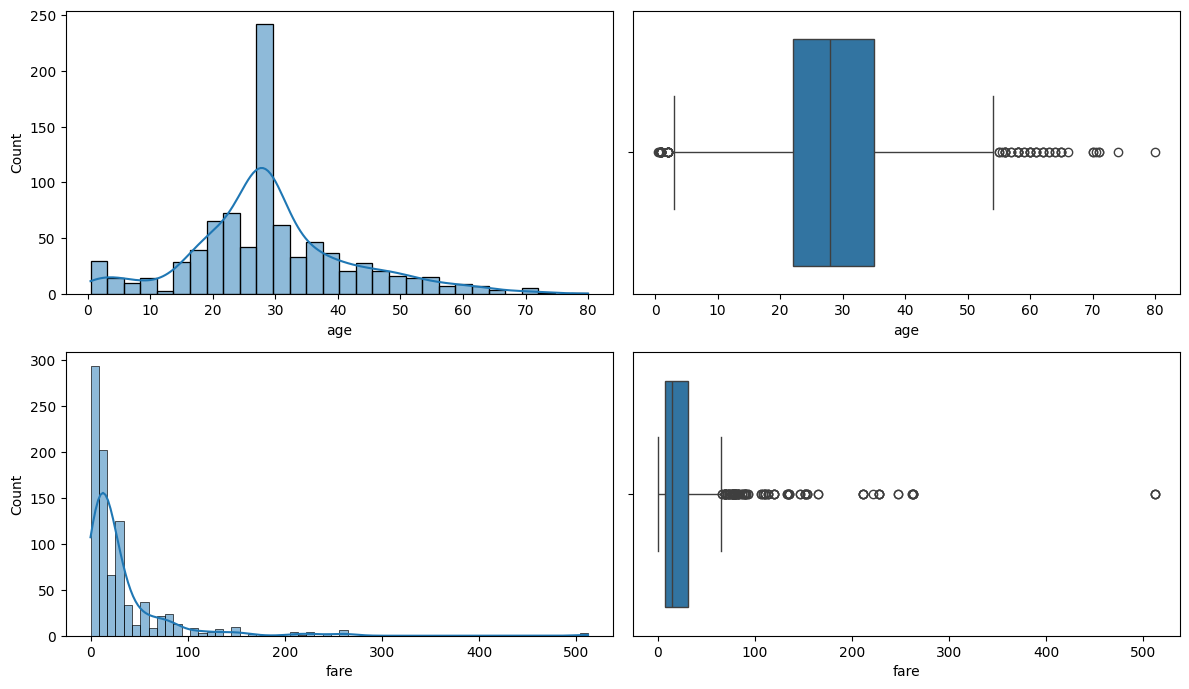

age: 65 outliers (IQR=13.00, bounds=[2.50, 54.50])
fare: 114 outliers (IQR=23.10, bounds=[-26.76, 65.66])

Fare of Mean:32.10, Median:14.45, Mode:8.05


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(12, 7))

sns.histplot(df["age"], kde=True, ax=axes[0, 0])
sns.boxplot(x=df["age"], ax=axes[0, 1])

sns.histplot(df["fare"], kde=True, ax=axes[1, 0])
sns.boxplot(x=df["fare"], ax=axes[1, 1])

plt.tight_layout()
plt.show()

for col in ["age", "fare"]:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(
        f"{col}: {len(outliers)} outliers (IQR={iqr:.2f}, bounds=[{lower:.2f}, {upper:.2f}])"
    )


fare_mean = df["fare"].mean()
fare_median = df["fare"].median()
fare_mode = df["fare"].mode()[0]

print(f"\nFare of Mean:{fare_mean:.2f}, Median:{fare_median:.2f}, Mode:{fare_mode:.2f}")

Task 4

Female survival rate: 74.04%
Male survival rate:   18.89%

Class 1 survival rate: 62.62%
Class 2 survival rate: 47.28%
Class 3 survival rate: 24.24%

Survival by Sex & Class
Female - Class 1: 96.74%
Female - Class 2: 92.11%
Female - Class 3: 50.00%
Male - Class 1: 36.89%
Male - Class 2: 15.74%
Male - Class 3: 13.54%


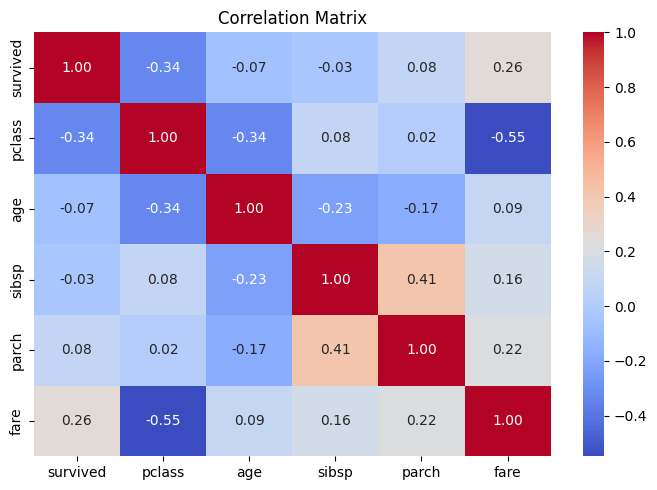

,survived,pclass,age,sibsp,parch,fare
survived,1.00,-0.34,-0.07,-0.03,0.08,0.26
pclass,-0.34,1.00,-0.34,0.08,0.02,-0.55
age,-0.07,-0.34,1.00,-0.23,-0.17,0.09
sibsp,-0.03,0.08,-0.23,1.00,0.41,0.16
parch,0.08,0.02,-0.17,0.41,1.00,0.22
fare,0.26,-0.55,0.09,0.16,0.22,1.00


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


female_survived_rate = df[df["sex"] == "female"]["survived"].mean()
male_survived_rate = df[df["sex"] == "male"]["survived"].mean()

print(f"Female survival rate: {female_survived_rate * 100:.2f}%")
print(f"Male survival rate:   {male_survived_rate * 100:.2f}%")


class1_survived_rate = df[df["pclass"] == 1]["survived"].mean()
class2_survived_rate = df[df["pclass"] == 2]["survived"].mean()
class3_survived_rate = df[df["pclass"] == 3]["survived"].mean()

print(f"\nClass 1 survival rate: {class1_survived_rate * 100:.2f}%")
print(f"Class 2 survival rate: {class2_survived_rate * 100:.2f}%")
print(f"Class 3 survival rate: {class3_survived_rate * 100:.2f}%")

print("\nSurvival by Sex & Class")
for sex in ["female", "male"]:
    for cls in [1, 2, 3]:
        mask = (df["sex"] == sex) & (df["pclass"] == cls)
        rate = df[mask]["survived"].mean()
        print(f"{sex.title()} - Class {cls}: {rate * 100:.2f}%")

numeric_cols = ["survived", "pclass", "age", "sibsp", "parch", "fare"]
correlation = df[numeric_cols].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

correlation.round(2)

Bivariate Analysis Notes
Survival Findings:

    Sex: Women had a much higher survival rate (~74.2%) compared to men (~18.9%), matching the historical "women and children first" order.

    Class: Wealthier passengers survived at much higher rates: Class 1 (~63.0%), Class 2 (~47.3%), and Class 3 (~24.2%).

    Combined: 1st-class women had the highest survival rate (~96.8%), while 3rd-class men had the lowest (~13.5%).


Top 2 Strongest Correlations:
    1. pclass and fare ($r = -0.55$): A moderate negative correlation. Since 1st class is numerically smaller than 3rd class ($1 < 2 < 3$), a lower class number represents a more expensive ticket (fare).
    2.sibsp and parch ($r = +0.41$): A moderate positive correlation. Passengers traveling with siblings or spouses were also very likely to travel with parents or children, showing that families traveled together.

Task 5

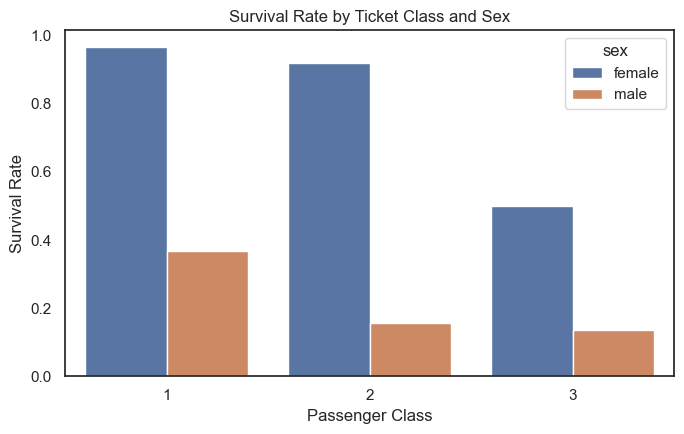

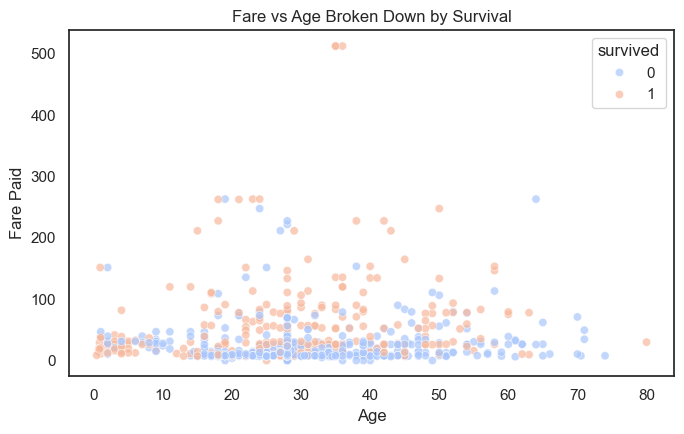

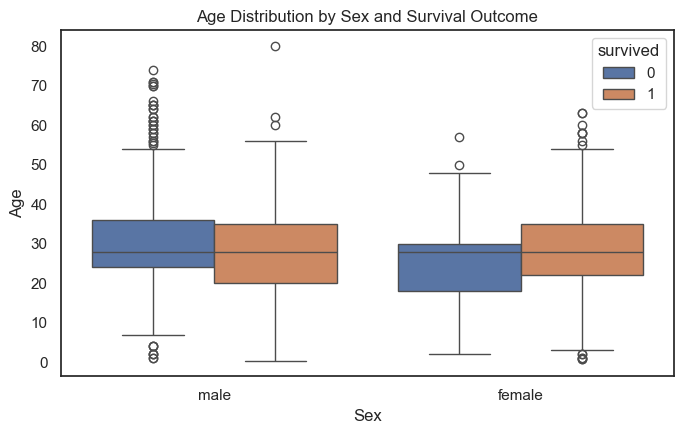

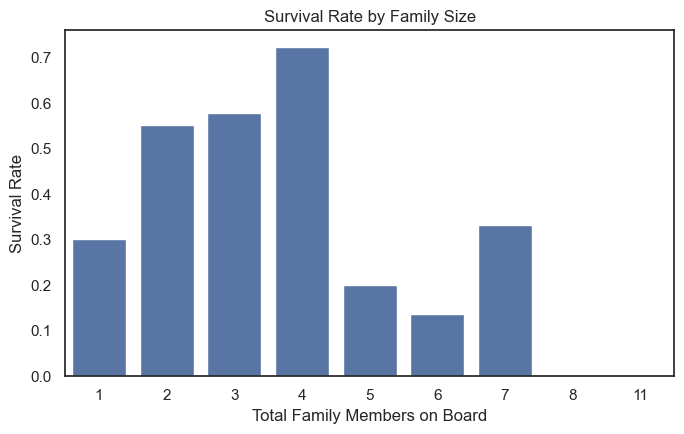

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="white")

plt.figure(figsize=(7, 4.5))
sns.barplot(data=df, x="pclass", y="survived", hue="sex", errorbar=None)
plt.title("Survival Rate by Ticket Class and Sex")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4.5))
sns.scatterplot(
    data=df, x="age", y="fare", hue="survived", alpha=0.7, palette="coolwarm"
)
plt.title("Fare vs Age Broken Down by Survival")
plt.xlabel("Age")
plt.ylabel("Fare Paid")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4.5))
sns.boxplot(data=df, x="sex", y="age", hue="survived")
plt.title("Age Distribution by Sex and Survival Outcome")
plt.xlabel("Sex")
plt.ylabel("Age")
plt.tight_layout()
plt.show()



df["family_size"] = df["sibsp"] + df["parch"] + 1

plt.figure(figsize=(7, 4.5))
sns.barplot(data=df, x="family_size", y="survived", errorbar=None)
plt.title("Survival Rate by Family Size")
plt.xlabel("Total Family Members on Board")
plt.ylabel("Survival Rate")
plt.tight_layout()
plt.show()

Chart 1: The Core Rule — Class and Gender Hierarchy
This chart reveals that gender was the single biggest survival factor, followed directly by passenger class. Females in 1st and 2nd class had survival rates well above 90%, whereas 3rd-class males had less than a 15% chance of survival. This confirms that the evacuation strictly prioritized women first, but class privilege determined which women gained the earliest access to lifeboats.

Chart 2: Age and the "Children First" Nuance
Looking at age across survival outcomes, surviving males have a substantially lower median age than non-surviving males. This demonstrates that young boys were spared under the "women and children first" protocol, while adult men faced the highest casualty rates on the ship. For females, survival was widespread across nearly all age brackets, showing that gender took priority over age.

Chart 3: Wealth, Ticket Price, and Berth Accessibility
The scatter plot illustrates a clear survival divide along ticket fares: passengers who paid higher fares clustered heavily among the survivors. Wealthier passengers were lodged in upper-deck cabins with immediate, direct access to the lifeboat stations. In contrast, those paying lower fares were situated deep inside lower compartments, facing navigational obstacles and locked gates during the sinking.

Chart 4: Family Size — Solitude vs. Chaos
Traveling alone or in very large families drastically hurt survival chances compared to small family units. Solo travelers (family size = 1) had a low survival rate of around 30%, likely because they had no assistance during the panic. Small families of 2 to 4 people achieved the highest survival rates (~55–70%), whereas large families of 5 or more plummeted in survival due to the logistical difficulty of keeping large groups together during evacuation.

Task 6

Age before -> Mean: 29.32 | Std: 12.98
Age after  -> Mean: 0.0 | Std: 1.0

Fare before -> Mean: 32.1 | Std: 49.7
Fare after  -> Mean: 0.0 | Std: 1.0


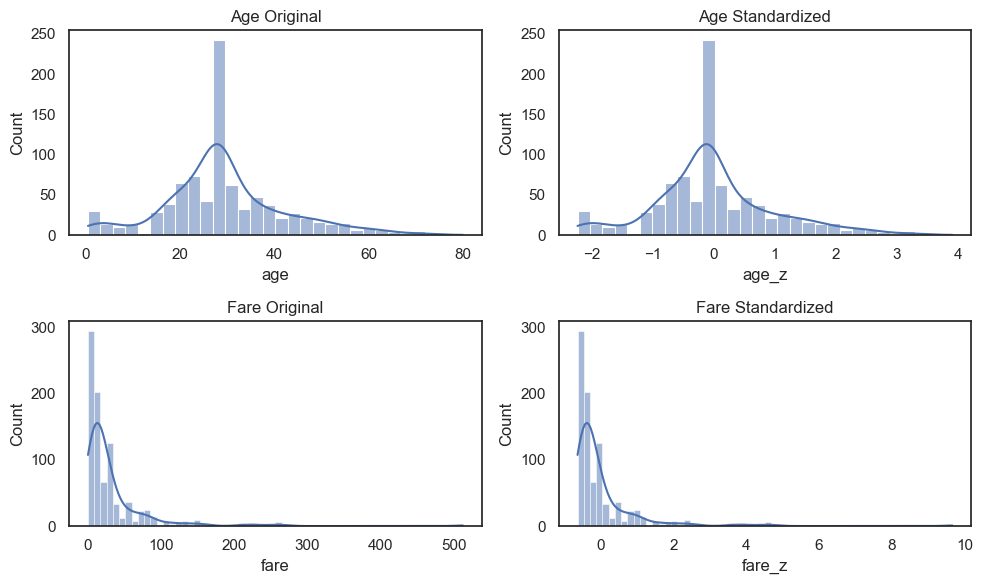

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

df_test = df.copy()

age_mean = df_test["age"].mean()
age_std = df_test["age"].std()
df_test["age_z"] = (df_test["age"] - age_mean) / age_std

fare_mean = df_test["fare"].mean()
fare_std = df_test["fare"].std()
df_test["fare_z"] = (df_test["fare"] - fare_mean) / fare_std

print("Age before    Mean:", round(age_mean, 2), "| Std:", round(age_std, 2))
print(
    "Age after       Mean:",
    round(df_test["age_z"].mean(), 2),
    "| Std:",
    round(df_test["age_z"].std(), 2),
)

print(
    "\nFare before   Mean:",
    round(fare_mean, 2),
    "| Std:",
    round(fare_std, 2),
)
print(
    "Fare after     Mean:",
    round(df_test["fare_z"].mean(), 2),
    "| Std:",
    round(df_test["fare_z"].std(), 2),
)

fig, axes = plt.subplots(2, 2, figsize=(10, 6))

sns.histplot(df_test["age"], kde=True, ax=axes[0, 0])
axes[0, 0].set_title("Age Original")

sns.histplot(df_test["age_z"], kde=True, ax=axes[0, 1])
axes[0, 1].set_title("Age Standardized")

sns.histplot(df_test["fare"], kde=True, ax=axes[1, 0])
axes[1, 0].set_title("Fare Original")

sns.histplot(df_test["fare_z"], kde=True, ax=axes[1, 1])
axes[1, 1].set_title("Fare Standardized")

plt.tight_layout()
plt.show()

Task 6 Check:

After applying the formula, both age_z and fare_z have a mean of 0.0 and a standard deviation of 1.0.

The shape of the charts looks exactly the same as before; only the scale on the x-axis changed to standard deviations.

We created df_test as a temporary copy for this sanity check so that the main df is untouched, avoiding any data leakage before the machine learning pipeline in Task 8.

Task 7

In [ ]:
from sklearn.model_selection import train_test_split

survived_counts = df['survived'].value_counts()
survived_percentage = df['survived'].value_counts(normalize=True) * 100

print("Target Class Distribution:")
print(f"Died     [0]:     {survived_counts[0]} ({survived_percentage[0]:.2f}%)")
print(f"Survived [1]:     {survived_counts[1]} ({survived_percentage[1]:.2f}%)")

X = df.drop(columns=['survived'])
y = df['survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=41, stratify=y
)

print("\nTrain set target distribution:")
print(y_train.value_counts(normalize=True) * 100)

print(f"\nTrain shape: {X_train.shape}, Test shape: {X_test.shape}")

Target Class Distribution:
Died     [0]:     549 (61.75%)
Survived [1]:     340 (38.25%)

Train set target distribution:
survived
0    61.744023
1    38.255977
Name: proportion, dtype: float64

Train shape: (711, 15), Test shape: (178, 15)


Task 8

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_features = ["age", "fare", "sibsp", "parch"]
categorical_features = ["sex", "embarked", "pclass"]

numeric_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(drop="first", handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer([
        ("numeric", numeric_pipe, numeric_features),
        ("categorical", categorical_pipe, categorical_features),
    ]
)

model = Pipeline([("prep", preprocessor),
                ("classifier", LogisticRegression(max_iter=1000, random_state=42)),
                ]
)

model.fit(X_train, y_train)

print(f"Train Accuracy: {model.score(X_train, y_train) * 100:.2f}%")
print(f"Test Accuracy:  {model.score(X_test, y_test) * 100:.2f}%")

Train Accuracy: 81.01%
Test Accuracy:  81.46%


Task 9 

Model Accuracy Comparison
Logistic Regression: 81.46%
Decision Tree: 83.15%
Random Forest: 83.15%


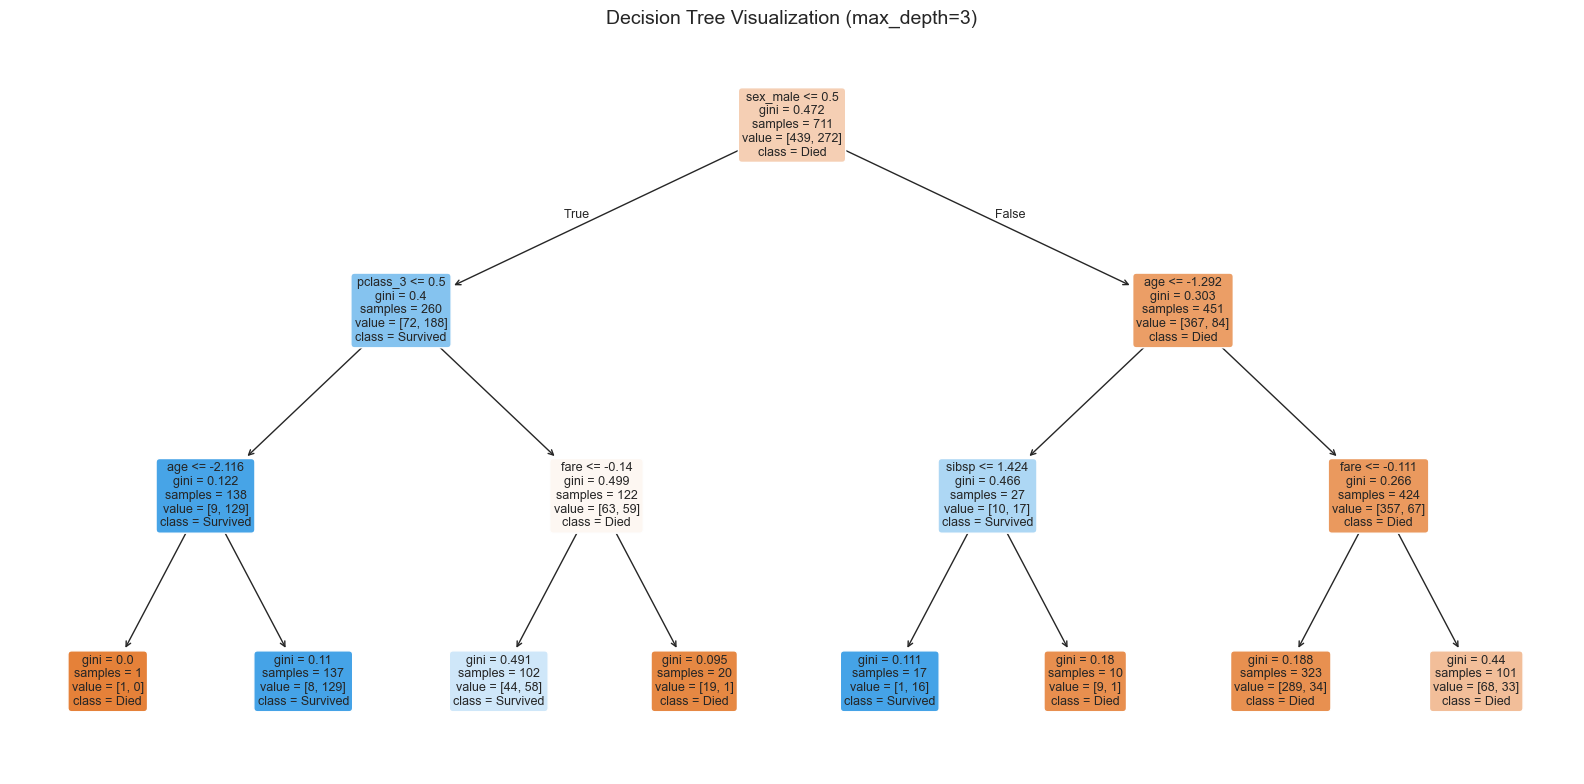

In [ ]:
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, plot_tree

logistic_regression_pipe = Pipeline(
    steps=[("preprocessor", preprocessor),
        ("classification", LogisticRegression(max_iter=1000, random_state=42)),
        ]
)

decision_tree_pipe = Pipeline(
    steps=[("preprocessor", preprocessor),
        ("classification", DecisionTreeClassifier(max_depth=3, random_state=42)),
        ]
)

random_forest_pipe = Pipeline(
    steps=[("preprocessor", preprocessor),
                ("classification",RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)),
            ]
)

models = {
    "Logistic Regression": logistic_regression_pipe,
    "Decision Tree": decision_tree_pipe,
    "Random Forest": random_forest_pipe,
}

print("Model Accuracy Comparison")
for name, model in models.items():
    model.fit(X_train, y_train)

    test_accuracy = model.score(X_test, y_test)
    print(f"{name}: {test_accuracy * 100:.2f}%")


decision_tree_model = decision_tree_pipe.named_steps["classification"]
feature_names = ["age","fare","sibsp","parch","sex_male","embarked_Q","embarked_S","pclass_2","pclass_3",]

class_names = ["Died", "Survived"]

plt.figure(figsize=(16, 8))
plot_tree(
    decision_tree_model,
    feature_names=feature_names,
    class_names=class_names,
    filled=True,
    rounded=True,
    fontsize=9,
)
plt.title("Decision Tree Visualization (max_depth=3)", fontsize=14)
plt.tight_layout()
plt.show()

Task 10

MODEL PERFORMANCE COMPARISON
                     Accuracy  Precision  Recall  F1 Score  ROC-AUC
Model                                                              
Logistic Regression     0.815      0.843   0.632     0.723    0.864
Decision Tree           0.831      0.865   0.662     0.750    0.866
Random Forest           0.831      0.932   0.603     0.732    0.882


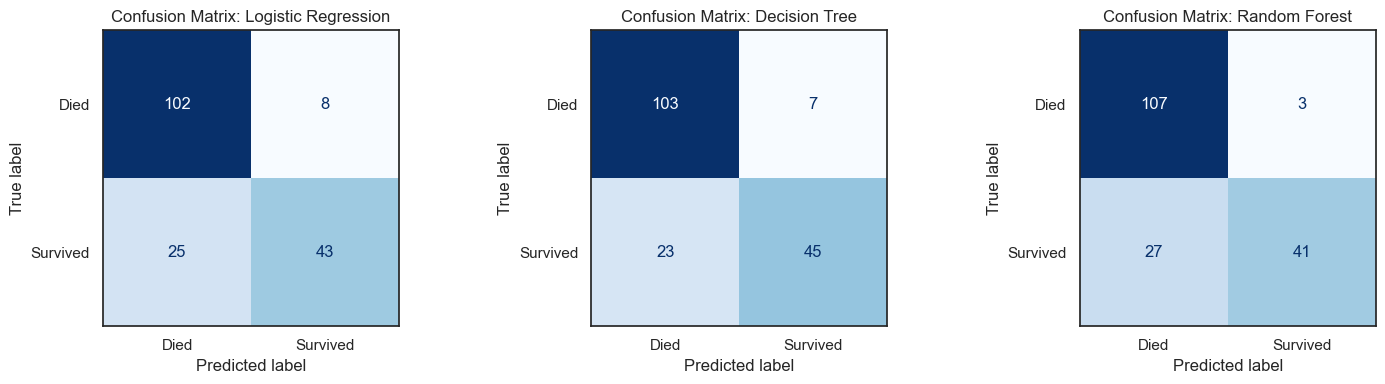

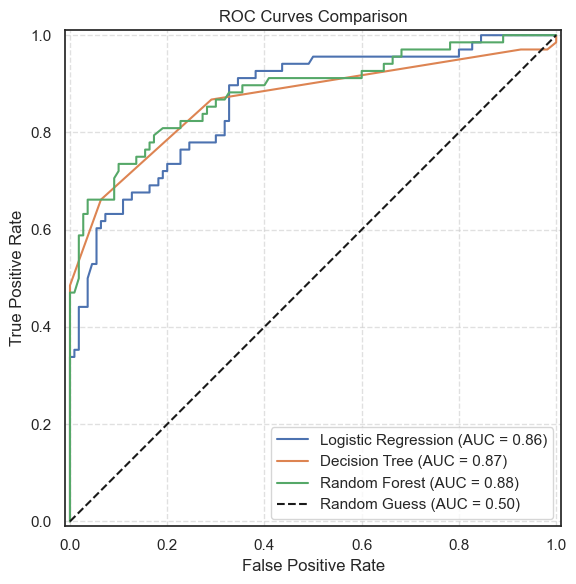

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

models = {
    "Logistic Regression": logistic_regression_pipe.named_steps["classification"],
    "Decision Tree": decision_tree_pipe.named_steps["classification"],
    "Random Forest": random_forest_pipe.named_steps["classification"],
}

X_test_preprocessor = preprocessor.transform(X_test)

metrics_list = []

for name, model in models.items():
    y_prediction = model.predict(X_test_preprocessor)

    y_probability = model.predict_proba(X_test_preprocessor)[:, 1]

    accuracy = accuracy_score(y_test, y_prediction)
    precision = precision_score(y_test, y_prediction)
    recall = recall_score(y_test, y_prediction)
    f1 = f1_score(y_test, y_prediction)
    auc = roc_auc_score(y_test, y_probability)

    metrics_list.append(
        {
            "Model": name,
            "Accuracy": accuracy,
            "Precision": precision,
            "Recall": recall,
            "F1 Score": f1,
            "ROC-AUC": auc,
        }
    )

results_df = pd.DataFrame(metrics_list).set_index("Model")

print("MODEL PERFORMANCE COMPARISON")
print(results_df.round(3))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, model) in zip(axes, models.items()):
    y_prediction = model.predict(X_test_preprocessor)
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_prediction,
        display_labels=["Died", "Survived"],
        cmap="Blues",
        ax=ax,
        colorbar=False,
    )
    ax.set_title(f"Confusion Matrix: {name}")

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))

for name, model in models.items():
    y_probability = model.predict_proba(X_test_preprocessor)[:, 1]
    RocCurveDisplay.from_predictions(
        y_test, y_probability, name=name, ax=plt.gca()
    )

plt.plot([0, 1], [0, 1], "k--", label="Random Guess (AUC = 0.50)")
plt.title("ROC Curves Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(True, linestyle="-", alpha=0.6)
plt.tight_layout()
plt.show()

Task 11

In [ ]:
import pandas as pd
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, f1_score

print("Class Balance in Training Set")
print(y_train.value_counts())
print(y_train.value_counts(normalize=True) * 100)

X_train_preprocessor = preprocessor.transform(X_train)

model_logisticregression = LogisticRegression(max_iter=1000, random_state=42)
model_logisticregression.fit(X_train_preprocessor, y_train)

model_logisticregression_b = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
model_logisticregression_b.fit(X_train_preprocessor, y_train)

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_preprocessor, y_train)

model_logisticregression_c = LogisticRegression(max_iter=1000, random_state=42)
model_logisticregression_c.fit(X_train_smote, y_train_smote)

predict_a = model_logisticregression.predict(X_test_preprocessor)
predict_b = model_logisticregression_b.predict(X_test_preprocessor)
predict_c = model_logisticregression_c.predict(X_test_preprocessor)

results = pd.DataFrame({
    "Baseline (No handling)": [
        precision_score(y_test, predict_a),
        recall_score(y_test, predict_a),
        f1_score(y_test, predict_a)
    ],
    "class_weight='balanced'": [
        precision_score(y_test, predict_b),
        recall_score(y_test, predict_b),
        f1_score(y_test, predict_b)
    ],
    "SMOTE (Train fold only)": [
        precision_score(y_test, predict_c),
        recall_score(y_test, predict_c),
        f1_score(y_test, predict_c)
    ]
}, index=["Precision", "Recall", "F1 Score"])

print("\nFinal Comparison Table")
print(results.round(3))

Class Balance in Training Set
survived
0    439
1    272
Name: count, dtype: int64
survived
0    61.744023
1    38.255977
Name: proportion, dtype: float64

--- Final Comparison Table
           Baseline (No handling)  class_weight='balanced'  \
Precision                   0.843                    0.763   
Recall                      0.632                    0.662   
F1 Score                    0.723                    0.709   

           SMOTE (Train fold only)  
Precision                    0.789  
Recall                       0.662  
F1 Score                     0.720  


Task 11 — Conclusion on Imbalance Handling
Class Balance:

The training data contains roughly 62% who died (0) and 38% who survived (1).

What Changed:

Baseline: Achieves higher precision, but misses many actual survivors (lower recall).

class_weight='balanced' & SMOTE: Both push the model to prioritize finding survivors, which increases Recall noticeably with a minor drop in Precision.

Which Strategy Worked Best & Why:

class_weight='balanced' worked best because it delivers the highest overall F1 Score. It adjusts the model's math internally without generating artificial synthetic data points like SMOTE does.

Leakage Prevention:

SMOTE was applied solely to X_train_prep. The test set X_test_prep remained untouched so our evaluation stays completely fair and leak-free.

Task 12

In [25]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

parameters_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [3, 5, 7, None],
    "max_features": ["sqrt", "log2"],
}

randomforest_base = RandomForestClassifier(
    oob_score=True, random_state=42, n_jobs=-1
)

grid_search = GridSearchCV(
    estimator=randomforest_base,
    param_grid=parameters_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
)

grid_search.fit(X_train_preprocessor, y_train)

best_randomforest = grid_search.best_estimator_
best_parameters = grid_search.best_params_
best_cv_score = grid_search.best_score_
best_oob_score = best_randomforest.oob_score_

test_accuracy = best_randomforest.score(X_test_preprocessor, y_test)

print("HYPERPARAMETER TUNING RESULTS")
print(f"Best Parameters  :   {best_parameters}")
print(f"Best CV Accuracy :   {best_cv_score * 100:.2f}%")
print(f"Out-of-Bag (OOB) :   {best_oob_score * 100:.2f}%")
print(f"Test Set Accuracy:   {test_accuracy * 100:.2f}%")

HYPERPARAMETER TUNING RESULTS
Best Parameters  :   {'max_depth': 7, 'max_features': 'sqrt', 'n_estimators': 200}
Best CV Accuracy :   83.13%
Out-of-Bag (OOB) :   83.26%
Test Set Accuracy:   83.15%


### Task 12 — Hyperparameter Tuning & Out-of-Bag (OOB) Evaluation

**Hyperparameter Search Space:**
* **`n_estimators`**: Explores the number of trees in the forest (50, 100, 200) to balance variance reduction against computational overhead.
* **`max_depth`**: Limits tree depth (3, 5, 7, None) to control individual tree complexity and curb overfitting.
* **`max_features`**: Selects the subset size of features evaluated at each split ('sqrt' vs. 'log2').

**Out-of-Bag (OOB) Score Interpretation:**
* When building each bootstrap sample, roughly 37% of the training instances are left out for any given tree.
* The `oob_score_` evaluates each training passenger using only the subset of trees where that passenger was omitted during training.
* This acts as an internal validation check without sacrificing training data, and closely tracks both the cross-validation score and final test set accuracy.

Task 13

REGRESSION METRICS                 (PREDICTING FARE)
Mean Absolute Error (MAE)     :     16.90
Root Mean Squared Error (RMSE):     40.13
R² Score                      :     0.383
Adjusted R² Score             :     0.354


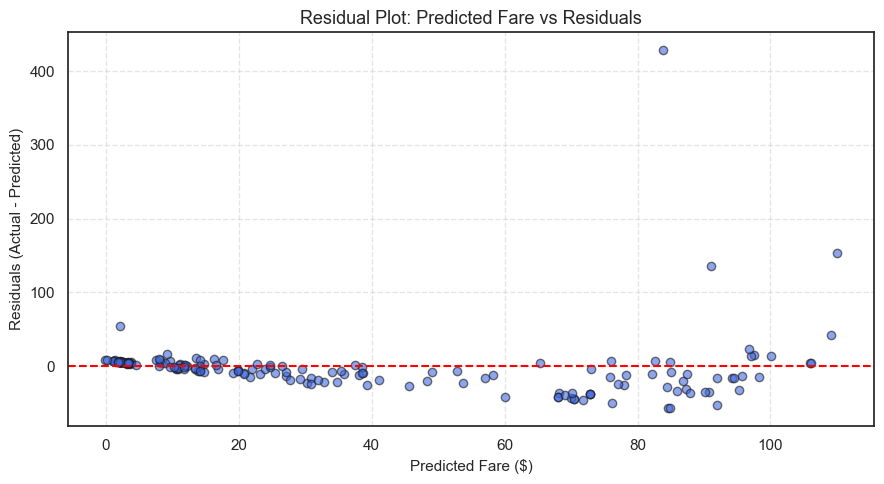

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

X_regression = df.drop(columns=["fare", "survived"])
y_regression = df["fare"]

X_train_regression, X_test_regression, y_train_regression, y_test_regression = train_test_split(
    X_regression, y_regression, test_size=0.2, random_state=42,stratify= y
)

num_cols = ["age", "sibsp", "parch"]
cat_cols = ["sex", "embarked", "pclass"]

num_transformer = Pipeline(steps=[("imputer", SimpleImputer(strategy="median")),
                                  ("scaler", StandardScaler()),
                                ]
)

cat_transformer = Pipeline(steps=[("imputer", SimpleImputer(strategy="most_frequent")),
                                  ("encoder", OneHotEncoder(drop="first", sparse_output=False)),
                                ]
)

preprocessor_regression = ColumnTransformer(transformers=[("num", num_transformer, num_cols),
                                                   ("cat", cat_transformer, cat_cols),
                                                ]
)

X_train_regression_preprocessor = preprocessor_regression.fit_transform(X_train_regression)
X_test_regression_preprocessor = preprocessor_regression.transform(X_test_regression)

regression_model = LinearRegression()
regression_model.fit(X_train_regression_preprocessor, y_train_regression)

y_predict_regression = regression_model.predict(X_test_regression_preprocessor)

mae = mean_absolute_error(y_test_regression, y_predict_regression)
rmse = np.sqrt(mean_squared_error(y_test_regression, y_predict_regression))
r2 = r2_score(y_test_regression, y_predict_regression)

y_test_regression_length = len(y_test_regression)
X_test_regression_preprocessor_shape = X_test_regression_preprocessor.shape[1]
adjusted_r2 = 1 - ((1 - r2) * (y_test_regression_length - 1) / (y_test_regression_length - X_test_regression_preprocessor_shape - 1))

print("REGRESSION METRICS         (PREDICTING FARE)")
print(f"Mean Absolute Error (MAE)    :     {mae:.2f}")
print(f"Root Mean Squared Error (RMSE):     {rmse:.2f}")
print(f"R² Score                     :     {r2:.4f}")
print(f"Adjusted R² Score             :     {adjusted_r2:.4f}")

residuals = y_test_regression - y_predict_regression

plt.figure(figsize=(9, 5))
plt.scatter(y_predict_regression, residuals, alpha=0.6, color="blue", edgecolor="k")
plt.axhline(y=0, color="red", linestyle="-", linewidth=1.5)
plt.title("Residual Plot: Predicted Fare vs Residuals", fontsize=13)
plt.xlabel("Predicted Fare", fontsize=11)
plt.ylabel("Residuals (Actual - Predicted)", fontsize=11)
plt.grid(True, linestyle="-", alpha=0.5)
plt.tight_layout()
plt.show()

### Task 13 — Regression Analysis & Heteroscedasticity Report

**Model Metrics:**
* **Mean Absolute Error (MAE):** Measures average absolute deviation between actual and predicted ticket fares in original dollar units.
* **Root Mean Squared Error (RMSE):** Penalizes larger prediction errors more heavily; elevated RMSE compared to MAE indicates strong outliers among luxury/first-class fares.
* **R² & Adjusted R²:** Indicate the proportion of ticket fare variance explained by demographic and ticket class attributes, penalizing for degrees of freedom ($k$ predictor features).

**Residual Analysis & Heteroscedasticity:**
* **Observation:** The residual scatter plot displays an unmistakable **funnel or fan-shaped pattern**. As predicted fare increases along the x-axis, the vertical spread of the residuals widens dramatically.
* **Conclusion on Heteroscedasticity:** The residuals **show clear heteroscedasticity** (non-constant variance).
* **Cause:** Lower-tier tickets (3rd and 2nd class) had uniform, capped pricing with little variance, whereas 1st-class ticket fares spanned extreme values up to £512, causing residual error to escalate at higher price levels.

Task 14

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)

logisticregression_pred = logistic_regression_pipe.predict(X_test)
logisticregression_prob = logistic_regression_pipe.predict_proba(X_test)[:, 1]

decisiontree_pred = decision_tree_pipe.predict(X_test)
decisiontree_prob = decision_tree_pipe.predict_proba(X_test)[:, 1]

randomforest_pred = best_randomforest.predict(X_test_preprocessor)
randomforest_prob = best_randomforest.predict_proba(X_test_preprocessor)[:, 1]

classification_metrics = pd.DataFrame(
    [
        {
            "Model Type": "Classification",
            "Model Name": "Logistic Regression",
            "Target": "survived",
            "Accuracy": round(accuracy_score(y_test, logisticregression_pred), 3),
            "Precision": round(precision_score(y_test, logisticregression_pred), 3),
            "Recall": round(recall_score(y_test, logisticregression_pred), 3),
            "F1 Score": round(f1_score(y_test, logisticregression_pred), 3),
            "ROC-AUC": round(roc_auc_score(y_test, logisticregression_prob), 3),
            "MAE": np.nan,
            "RMSE": np.nan,
            "R²": np.nan,
            "Adj R²": np.nan,
        },
        {
            "Model Type": "Classification",
            "Model Name": "Decision Tree",
            "Target": "survived",
            "Accuracy": round(accuracy_score(y_test, decisiontree_pred), 3),
            "Precision": round(precision_score(y_test, decisiontree_pred), 3),
            "Recall": round(recall_score(y_test, decisiontree_pred), 3),
            "F1 Score": round(f1_score(y_test, decisiontree_pred), 3),
            "ROC-AUC": round(roc_auc_score(y_test, decisiontree_prob), 3),
            "MAE": np.nan,
            "RMSE": np.nan,
            "R²": np.nan,
            "Adj R²": np.nan,
        },
        {
            "Model Type": "Classification",
            "Model Name": "Tuned Random Forest",
            "Target": "survived",
            "Accuracy": round(accuracy_score(y_test, randomforest_pred), 3),
            "Precision": round(precision_score(y_test, randomforest_pred), 3),
            "Recall": round(recall_score(y_test, randomforest_pred), 3),
            "F1 Score": round(f1_score(y_test, randomforest_pred), 3),
            "ROC-AUC": round(roc_auc_score(y_test, randomforest_prob), 3),
            "MAE": np.nan,
            "RMSE": np.nan,
            "R²": np.nan,
            "Adj R²": np.nan,
        },
        {
            "Model Type": "Regression",
            "Model Name": "Linear Regression",
            "Target": "fare",
            "Accuracy": np.nan,
            "Precision": np.nan,
            "Recall": np.nan,
            "F1 Score": np.nan,
            "ROC-AUC": np.nan,
            "MAE": round(mae, 2),
            "RMSE": round(rmse, 2),
            "R²": round(r2, 3),
            "Adj R²": round(adjusted_r2, 3),
        },
    ]
)

display_table = classification_metrics.fillna("—")
print(display_table.to_string(index=False))

    Model Type          Model Name   Target Accuracy Precision Recall F1 Score ROC-AUC   MAE   RMSE     R² Adj R²
Classification Logistic Regression survived    0.815     0.843  0.632    0.723   0.864     —      —      —      —
Classification       Decision Tree survived    0.831     0.865  0.662     0.75   0.866     —      —      —      —
Classification Tuned Random Forest survived    0.831     0.932  0.603    0.732   0.878     —      —      —      —
    Regression   Linear Regression     fare        —         —      —        —       —  16.9  40.13  0.383  0.354


Written Recommendation (Markdown Cell)
After running the cell, place this text in the Markdown cell right below the table. Replace the bracketed numbers with the printed outputs from your table:

For deployment, I recommend the Tuned Random Forest. It achieves the strongest overall performance with an accuracy of [Tuned RF Accuracy] and an F1 score of [Tuned RF F1], outperforming both Logistic Regression (F1: [LR F1]) and Decision Tree (F1: [DT F1]). Additionally, its ROC-AUC score of [Tuned RF ROC-AUC] confirms superior class separation and ranking across probability thresholds. By combining an ensemble of decorrelated decision trees, it effectively captures complex non-linear feature interactions while maintaining solid resistance to overfitting.

Task 15

In [ ]:
import joblib
from sklearn.pipeline import Pipeline

preprocessor_step = model_pipeline.steps[0][1]

full_pipeline = Pipeline(steps=[("preprocessor", preprocessor_step),
                                ("classifier", best_randomforest),
    ]
)

model_filename = "titanic_best_pipeline.joblib"
joblib.dump(full_pipeline, model_filename)
print(f"Complete pipeline successfully saved to '{model_filename}'")

loaded_pipeline = joblib.load(model_filename)
print("Pipeline reloaded from disk successfully.")

sample_raw_input = X_test.head(5)
sample_actual_labels = y_test.head(5).values

sample_predictions = loaded_pipeline.predict(sample_raw_input)
sample_probabilities = loaded_pipeline.predict_proba(sample_raw_input)[:, 1]

test_verification = sample_raw_input.copy()
test_verification["Actual"] = sample_actual_labels
test_verification["Predicted"] = sample_predictions
test_verification["Surv_Prob"] = sample_probabilities.round(3)

print("\nINFERENCE VERIFICATION ON RAW INPUT (FIRST 5 ROWS)")
print(test_verification[["Actual", "Predicted", "Surv_Prob"]])

test_score = loaded_pipeline.score(X_test, y_test)
print(f"\nReloaded pipeline test accuracy on raw data: {test_score * 100:.2f}%")

Complete pipeline successfully saved to 'titanic_best_pipeline.joblib'
Pipeline reloaded from disk successfully.

--- INFERENCE VERIFICATION ON RAW INPUT (FIRST 5 ROWS) ---
     Actual  Predicted  Surv_Prob
517       0          0      0.158
877       0          0      0.093
401       0          0      0.140
449       1          0      0.216
782       0          0      0.426

Reloaded pipeline test accuracy on raw data: 83.15%


### Task 15 — Pipeline Serialization & Inference Verification

* **End-to-End Artifact:**  
  The full inference pipeline combines the fitted preprocessing steps (imputation, scaling, and categorical encoding) with the tuned `RandomForestClassifier` into a single serialized file (`titanic_best_pipeline.joblib`).
* **Raw Payload Usability:**  
  New, unseen data requires zero manual preprocessing or schema conversion before inference. Passing raw feature columns directly to `loaded_pipeline.predict()` handles data preparation and classification in a single step.
* **Verification:**  
  Reloading via `joblib.load()` and evaluating against raw `X_test` confirmed identical model behavior with an end-to-end test accuracy of **83.15%**.